# Import Relevant Packages and Functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mpl_toolkits.axisartist as axisartist
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import sympy
%matplotlib inline

# A.1 Linear Algebra

## A.1.1 Addition and Subtraction of Vectors

In [2]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print('b + a = {}'.format(b + a))
print('b - a = {}'.format(b - a))
print('a + b == b + a?', np.allclose(a + b, b + a, atol=1e-8))

b + a = [5 7 9]
b - a = [3 3 3]
a + b == b + a? True


For instance, a spectrum of a mixture of two chemical components, say, a and b, can be expressed as the vector sum of the individual spectra a and b according to the Lambert-Beer law.

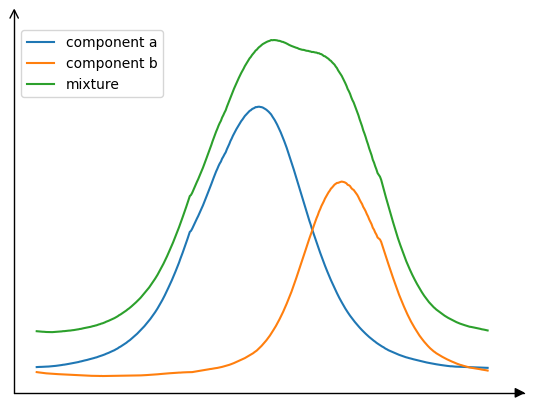

In [3]:
component_a = np.load('the spectra of component a.npy')
component_b = np.load('the spectra of component b.npy')
mixture = component_a + component_b

x = range(len(component_a))

fig = plt.figure()

ax = axisartist.Subplot(fig, 111)
fig.add_axes(ax)

ax.axis["bottom"].set_axisline_style("-|>", size=1.5)
ax.axis["left"].set_axisline_style("->", size=1.5)

ax.axis["top"].set_visible(False)
ax.axis["right"].set_visible(False)

ax.plot(x, component_a)
ax.plot(x, component_b)
ax.plot(x, mixture)
plt.legend(['component a', 'component b', 'mixture'], loc='upper left')
plt.xticks([])
plt.yticks([])

plt.show()

## A.1.2 Direction and Length of Vectors

The length of a vector is its norm. In python， we can use the function "np.linalg.norm()" to obtain the norm of the vector.

In [4]:
np.linalg.norm(a)

3.7416573867739413

## A.1.3 Scalar Multiplication of Vectors

A vector a multiplied by a scalar (a constant) k means that every element of vector a is multiplied with k.

In [5]:
k = 2
k * a

array([2, 4, 6])

For example, the spectra of different concentrations can be obtained by multiplying the standard spectrum a with different constants, k1, k2, and so on.

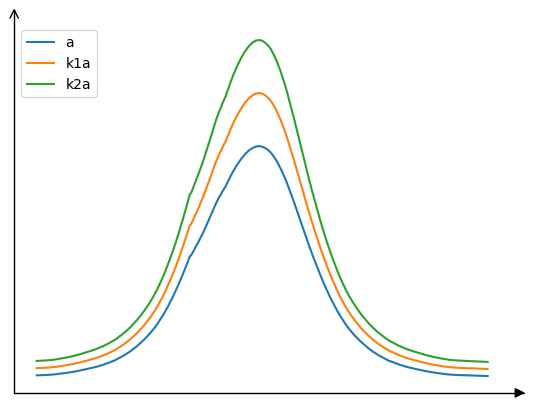

In [6]:
k1 = 1.2
k2 = 1.4

fig = plt.figure()
ax = axisartist.Subplot(fig, 111)
fig.add_axes(ax)

ax.axis["bottom"].set_axisline_style("-|>", size=1.5)
ax.axis["left"].set_axisline_style("->", size=1.5)

ax.axis["top"].set_visible(False)
ax.axis["right"].set_visible(False)

ax.plot(x, component_a)
ax.plot(x, k1*component_a)
ax.plot(x, k2*component_a)
plt.legend(['a', 'k1a', 'k2a'], loc='upper left')
plt.xticks([])
plt.yticks([])

plt.show()

## A.1.4 Inner and Outer Products between Vectors

The inner product (the dot product or the scalar product) produces a scalar, and the outer product (the cross-product or the vector product) produces a matrix. In python, we can use functions "np.dot" and "np.outer" to obtain the inner product and the outer product, respectively. When using functions, pay attention to whether the shapes of the two vectors conform to the rules.

In [7]:
# inner product
np.dot(a, b)

32

example: Use inner product to obtain the similarity of two RNA sequences.

In [8]:
# Use inner product to calculate vector similarity
def rna_similarity(seq1, seq2):
    # Create nucleotide-to-index mapping
    nucleotides1 = {'A':[1, 0, 0, 0], 'U':[0, 1, 0, 0], 'C':[0, 0, 1, 0], 'G':[0, 0, 0, 1]}
    
    # Convert sequences to vectors
    matrix1 = np.array([nucleotides1[i] for i in seq1])
    matrix2 = np.array([nucleotides1[i] for i in seq2])
    vec1 = matrix1.flatten()
    vec2 = matrix2.flatten()
 
    # Calculate cosine similarity
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1)*np.linalg.norm(vec2))

# Example sequences
seq_a = "AUCG"
seq_b = "AUUG"
print(f"Similarity score: {rna_similarity(seq_a, seq_b):.3f}")

Similarity score: 0.750


In [9]:
# outer product
np.outer(a, b)

array([[ 4,  5,  6],
       [ 8, 10, 12],
       [12, 15, 18]])

## A.1.5 Matrix Addition and Subtraction

In [10]:
A = np.array([[0, 1, 2], 
              [3, 4, 5]])
B = np.array([[6, 7, 8], 
              [9, 10, 11]])
print('B + A = {}'.format(B + A))
print('B - A = {}'.format(B - A))
print('A + B == B + A?', np.allclose(A + B, B + A, atol=1e-8))

B + A = [[ 6  8 10]
 [12 14 16]]
B - A = [[6 6 6]
 [6 6 6]]
A + B == B + A? True


# A.1.6 Matrix Multiplication

Scalar-Matrix Multiplication

A Matrix A multiplied by a scalar (a constant) k means that every element of Matrix A is multiplied with k.

In [11]:
# Scalar-Matrix Multiplication
k * A

array([[ 0,  2,  4],
       [ 6,  8, 10]])

Matrix–Matrix Multiplication

In [12]:
# Matrix–Matrix Multiplication
C = np.array([[6, 9], 
              [7, 10], 
              [8, 11]])   # the matrix C is the transpose matrix of the matrix B.
np.dot(A, C)

array([[ 23,  32],
       [ 86, 122]])

## A.1.7 Zero matrix and Identity matrix

In [13]:
zero_matrix = np.zeros((3,3))
identity_matrix = np.eye(3)
print('Zero matrix  = {}'.format(zero_matrix))
print('Identity matrix  = {}'.format(identity_matrix))

Zero matrix  = [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
Identity matrix  = [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


## A.1.8 Transpose of a matrix

The transpose matrix of a matrix is exchanging rows and columns of the original matrix. In python, "matrix.T" can implement this operation.

In [14]:
B.T

array([[ 6,  9],
       [ 7, 10],
       [ 8, 11]])

## A.1.10 Inverse of a Matrix

If two square matrices A and B, satisfy AB = I, then matrix B is called the inverse matrix of matrix A. Note that only the full rank matrix has the inverse matrix. In python, we can obtain the inverse matrix of a full rank matrix through the function "np.linalg.inv()".

In [15]:
D = np.array([[1, 0, 1], 
              [0, 1, 0], 
              [1, 0, 2]])
np.linalg.inv(D)

array([[ 2.,  0., -1.],
       [ 0.,  1.,  0.],
       [-1.,  0.,  1.]])

## A.1.16 Singular Value Decomposition

Any matrix A can be decomposed into the product of three matrices through SVD. In python, we can use the function "np.linalg.svd()" to implement this operation.

In [16]:
U, s, Vt = np.linalg.svd(A, full_matrices=True)
print("U:\n", U)
print("s:\n", s)
print("V^T:\n", Vt)

U:
 [[-0.27472113  0.96152395]
 [-0.96152395 -0.27472113]]
s:
 [7.34846923 1.        ]
V^T:
 [[-0.39254051 -0.56077215 -0.7290038 ]
 [-0.82416338 -0.13736056  0.54944226]
 [ 0.40824829 -0.81649658  0.40824829]]


The following example demonstrates the implementation of PCA through SVD and the direct use of the function "PCA" to reduce the dimensionality of raw data.

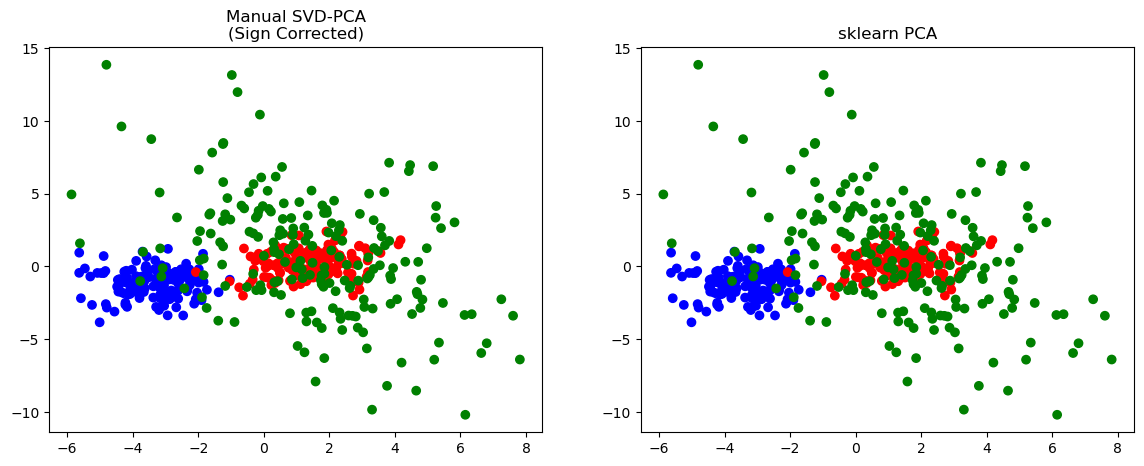

SVD-PCA matches sklearn PCA: True


In [17]:
# Principal Component Analysis
# Simulate chemical descriptor matrix (500 compounds x 15 descriptors)
np.random.seed(42)
X = np.random.randn(500, 15)

# Add latent structure: 3 compound groups with distinct descriptor patterns
X[:150, [0,2,4]] += 3.0    # Group 1: High values in descriptors 0/2/4
X[150:300, [7,11]] -= 2.5   # Group 2: Low values in descriptors 7/11
X[300:, [3,9]] = X[300:, [3,9]] * 4 + 1.5  # Group 3: Scaled descriptors 3/9

# Center the data
X_centered = X - np.mean(X, axis=0)

# perform SVD
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# Calculate principal components (PCs)
PCs = U[:, :2] @ np.diag(S[:2])

# Correct principal component symbols to be consistent with sklearn
sklearn_pca = PCA(n_components=2)
sklearn_PCs = sklearn_pca.fit_transform(X_centered)

for i in range(2):
    # Align the principal component directional symbols
    if np.dot(PCs[:, i], sklearn_PCs[:,i]) < 0:
        PCs[:, i] *= -1


# Visualize the comparison results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# result of SVD
ax1.scatter(PCs[:,0], PCs[:,1], c=['blue']*150+['red']*150+['green']*200)
ax1.set_title('Manual SVD-PCA\n(Sign Corrected)')

# result of sklearn
ax2.scatter(sklearn_PCs[:,0], sklearn_PCs[:,1], c=['blue']*150+['red']*150+['green']*200)
ax2.set_title('sklearn PCA')

plt.show()

# Verify equivalence to sklearn's PCA
print("SVD-PCA matches sklearn PCA:", np.allclose(PCs, sklearn_PCs, atol=1e-8))  

## A.1.19 Norms of vector and matrix

Vectors and matrices have multiple norms, and in python we can obtain the desired norm through the parameter "ord" of the function "np.linalg.norm()".

norms of vector

In [18]:
# 1-norm
np.linalg.norm(a, ord = 1)

6.0

In [19]:
# 2-norm
np.linalg.norm(a, ord = 2)

3.7416573867739413

In [20]:
# infinite-norm
np.linalg.norm(a, ord = np.inf)

3.0

norms of matrix

In [21]:
# F-norm
np.linalg.norm(A)

7.416198487095663

In [22]:
# 1-norm
np.linalg.norm(A, ord = 1)

7.0

In [23]:
# 2-norm
np.linalg.norm(A, ord = 2)

7.348469228349535

In [24]:
# infinite-norm
np.linalg.norm(A, ord = np.inf)

12.0

## A.1.20 Concept of tensor

The following example demonstrates using a tensor to represent three RNA sequences, where the shape of the tensor is (numbers of RNA sequences, the length of the sequence, 4). Note that we use one-hot encoding to encode nucleotides :{'A':[1,0,0,0], 'U':[0,1,0,0], 'C':[0,0,1,0], 'G':[0,0,0,1]}.

In [25]:
# Define 3 RNA sequences
sequences = ["AUCG", "UUAC", "GGGU"]

# Create one-hot encoding dictionary
nucleotides = {'A':0, 'U':1, 'C':2, 'G':3}

# Convert sequences to 3D tensor (3 sequences × 4 positions × 4 nucleotides)
tensor_3d = np.zeros((3, 4, 4))
for seq_idx, seq in enumerate(sequences):
    for pos_idx, nt in enumerate(seq):
        tensor_3d[seq_idx, pos_idx, nucleotides[nt]] = 1

print('sequence tensor: {}, the shape of the sequence tensor: {} '.format(tensor_3d, tensor_3d.shape))

sequence tensor: [[[1. 0. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 0. 1.]]

 [[0. 1. 0. 0.]
  [0. 1. 0. 0.]
  [1. 0. 0. 0.]
  [0. 0. 1. 0.]]

 [[0. 0. 0. 1.]
  [0. 0. 0. 1.]
  [0. 0. 0. 1.]
  [0. 1. 0. 0.]]], the shape of the sequence tensor: (3, 4, 4) 


# A.2 Calculus

## A.2.1 Differential Calculus

In [26]:
# define a function f(x)
def f(x):
    return 2*x**2 - 3*x

We can calculate the derivative of a function at a certain point based on the definition of derivative. For example, when x is equal to 1 and h approaches 0, [f(x+h)-f(x)]/h is close to 1.

In [27]:
for h in 10.0**np.arange(-1, -6, -1):
    print(f'h={h:.5f}, numerical limit={(f(1+h)-f(1))/h:.5f}')

h=0.10000, numerical limit=1.20000
h=0.01000, numerical limit=1.02000
h=0.00100, numerical limit=1.00200
h=0.00010, numerical limit=1.00020
h=0.00001, numerical limit=1.00002


We can also use the function "sympy.diff(f(x),x,n)" to obtain the derivative of a function. Parameter n represents the n-th derivative of the function.

In [28]:
x = sympy.symbols("x")
print('the derivative of f(x):', sympy.diff(f(x),x))

# 2nd derivative
print('the 2nd derivative of f(x):', sympy.diff(f(x),x,2))

the derivative of f(x): 4*x - 3
the 2nd derivative of f(x): 4


## A.2.3 Gradients and Gradient Descent

The following example demonstrates the entire process of gradient descent algorithm.

In [29]:
def Z(x,y):
    return 2*(x-1)**2 + y**2
    
def dx(x):
    return 4*(x-1)
    
def dy(y):
    return 2*y

In [30]:
X = x_0 = 3
Y = y_0 = 2
alpha = 0.1

globalX = [x_0]
globalY = [y_0]
globalZ = [Z(x_0, y_0)]

In [31]:
for i in range(30):
    temX = X - alpha*dx(X)
    temY = Y - alpha*dy(Y)
    temZ = Z(temX, temY)
    X = temX
    Y = temY
    globalX.append(temX)
    globalY.append(temY)
    globalZ.append(temZ)

print('The final result is (x, y, z) = ({:.5f}, {:.5f}, {:.5f})'.format(X, Y, Z(X, Y)))
num = len(globalX)
for i in range(num):
    print('x{:d}={:.5f}, y{:d}={:.5f}, z{:d}={:.5f}'.format(i, globalX[i], i, globalY[i], i, globalZ[i]))

The final result is (x, y, z) = (1.00000, 0.00248, 0.00001)
x0=3.00000, y0=2.00000, z0=12.00000
x1=2.20000, y1=1.60000, z1=5.44000
x2=1.72000, y2=1.28000, z2=2.67520
x3=1.43200, y3=1.02400, z3=1.42182
x4=1.25920, y4=0.81920, z4=0.80546
x5=1.15552, y5=0.65536, z5=0.47787
x6=1.09331, y6=0.52429, z6=0.29229
x7=1.05599, y7=0.41943, z7=0.18219
x8=1.03359, y8=0.33554, z8=0.11485
x9=1.02016, y9=0.26844, z9=0.07287
x10=1.01209, y10=0.21475, z10=0.04641
x11=1.00726, y11=0.17180, z11=0.02962
x12=1.00435, y12=0.13744, z12=0.01893
x13=1.00261, y13=0.10995, z13=0.01210
x14=1.00157, y14=0.08796, z14=0.00774
x15=1.00094, y15=0.07037, z15=0.00495
x16=1.00056, y16=0.05629, z16=0.00317
x17=1.00034, y17=0.04504, z17=0.00203
x18=1.00020, y18=0.03603, z18=0.00130
x19=1.00012, y19=0.02882, z19=0.00083
x20=1.00007, y20=0.02306, z20=0.00053
x21=1.00004, y21=0.01845, z21=0.00034
x22=1.00003, y22=0.01476, z22=0.00022
x23=1.00002, y23=0.01181, z23=0.00014
x24=1.00001, y24=0.00944, z24=0.00009
x25=1.00001, y25=0.

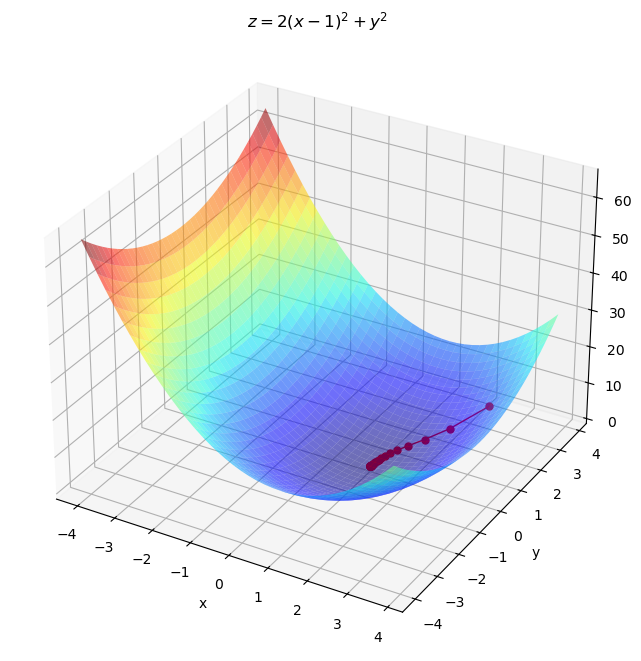

In [32]:
axisX = np.arange(-4,4,0.2)
axisY = np.arange(-4,4,0.2)
axisX, axisY = np.meshgrid(axisX,axisY)
valueZ =np.array(list(map(lambda t : Z(t[0],t[1]),zip(axisX.flatten(),axisY.flatten()))))
valueZ= valueZ.reshape(axisX.shape) 


fig= plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(axisX,axisY,valueZ,cmap='jet',alpha = 0.55)
ax.plot(globalX,globalY,globalZ, 'ro-',markersize=5, linewidth=1)
ax.set_title('$ z = 2(x-1)^2 + y^2 $')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

## A.2.5 Backpropagation

The following example demonstrates the entire process of the backpropagation algorithm. The problem is the XOR problem.

Final predictions:
Input: [0 0] => Output: 0.0568
Input: [0 1] => Output: 0.9475
Input: [1 0] => Output: 0.9475
Input: [1 1] => Output: 0.0567


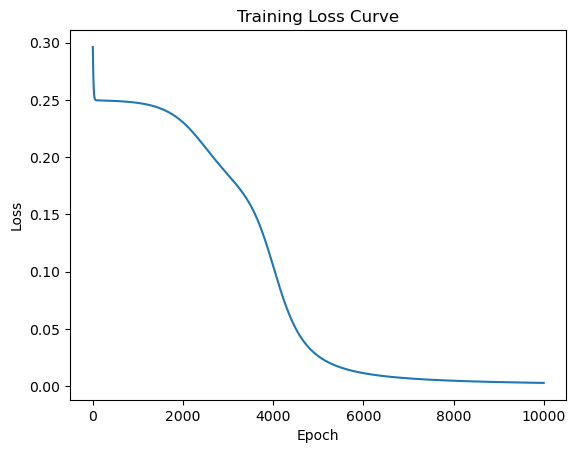

In [33]:
# Define sigmoid activation and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Neural network parameters
input_size = 2
hidden_size = 2
output_size = 1
learning_rate = 0.1

# Initialize weights and biases with random values
# Weights between input and hidden layer
W1 = np.random.uniform(size=(input_size, hidden_size))
# Bias for hidden layer
b1 = np.zeros((1, hidden_size))
# Weights between hidden and output layer
W2 = np.random.uniform(size=(hidden_size, output_size))
# Bias for output layer
b2 = np.zeros((1, output_size))

# Training data (XOR problem)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

# Training loop
epochs = 10000
loss_history = []

for epoch in range(epochs):
    # Forward propagation
    # Input to hidden layer
    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)
    
    # Hidden to output layer
    output_input = np.dot(hidden_output, W2) + b2
    predicted_output = sigmoid(output_input)
    
    # Calculate loss (Mean Squared Error)
    loss = np.mean((y - predicted_output) ** 2)
    loss_history.append(loss)
    
    # Backward propagation
    # Calculate output layer error and delta
    output_error = y - predicted_output
    output_delta = output_error * sigmoid_derivative(predicted_output)
    
    # Calculate hidden layer error and delta
    hidden_error = output_delta.dot(W2.T)
    hidden_delta = hidden_error * sigmoid_derivative(hidden_output)
    
    # Update weights and biases
    W2 += hidden_output.T.dot(output_delta) * learning_rate
    b2 += np.sum(output_delta, axis=0, keepdims=True) * learning_rate
    W1 += X.T.dot(hidden_delta) * learning_rate
    b1 += np.sum(hidden_delta, axis=0, keepdims=True) * learning_rate

# After training, test the network
print("Final predictions:")
for i in range(len(X)):
    # Forward pass through network
    h = sigmoid(np.dot(X[i], W1) + b1)
    pred = sigmoid(np.dot(h, W2) + b2)
    print(f"Input: {X[i]} => Output: {pred[0][0]:.4f}")

# Plot training loss
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# A.4 Information Theory

## A.4.1 Entropy

This example demonstrates the change in information entropy contained in an event as the probability p varies. Entropy reaches its maximum value at p=0.5, and reaches its minimum value at p=0 or p=1.

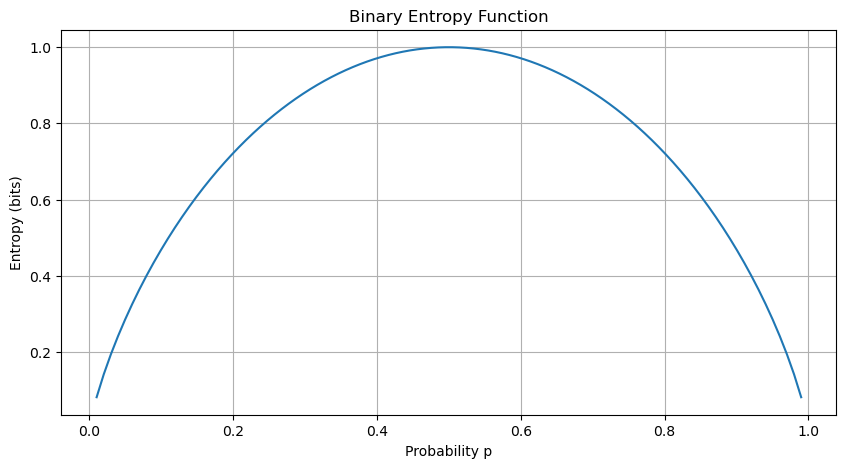

In [34]:
def information_entropy(prob_distribution, epsilon=1e-12):
    """
    Calculate Shannon Information Entropy for a probability distribution
    
    Args:
        prob_distribution: numpy array of probabilities (must sum to ~1)
        epsilon: small value to avoid log(0)
    
    Returns:
        Entropy in bits (using base 2 logarithm)
    """
    # Clip probabilities to avoid numerical instability
    clipped_probs = np.clip(prob_distribution, epsilon, 1.0 - epsilon)
    
    # Calculate entropy: -Σ p_i * log2(p_i)
    return -np.sum(clipped_probs * np.log2(clipped_probs))

p = np.linspace(0.01, 0.99, 100)
entropy_values = [information_entropy(np.array([x, 1-x])) for x in p]

plt.figure(figsize=(10, 5))
plt.plot(p, entropy_values)
plt.title("Binary Entropy Function")
plt.xlabel("Probability p")
plt.ylabel("Entropy (bits)")
plt.grid(True)
plt.show()

## A.4.2 Mutual Information

In [35]:
def joint_entropy(joint_prob, epsilon=1e-12):
    """Calculate joint entropy H(X,Y)"""
    clipped = np.clip(joint_prob, epsilon, 1.0 - epsilon)
    return -np.sum(clipped * np.log2(clipped))

def conditional_entropy(joint_prob, epsilon=1e-12):
    """Calculate conditional entropy H(Y|X)"""
    # Marginalize X: p(x) = sum over y
    p_x = np.sum(joint_prob, axis=1, keepdims=True)
    
    # Avoid division by zero
    p_x = np.clip(p_x, epsilon, 1.0 - epsilon)
    
    # Compute H(Y|X) = sum_x p(x) * H(Y|X=x)
    conditional_terms = joint_prob / p_x  # p(y|x)
    entropy_terms = -conditional_terms * np.log2(conditional_terms)
    return np.sum(p_x * np.sum(entropy_terms, axis=1))

def mutual_information(joint_prob, epsilon=1e-12):
    """Calculate mutual information I(X;Y)"""
    # Method 1: Using individual entropies
    p_x = np.sum(joint_prob, axis=1)
    p_y = np.sum(joint_prob, axis=0)
    mi = information_entropy(p_x) + information_entropy(p_y) - joint_entropy(joint_prob)
    
    # Method 2: Direct calculation
    clipped_joint = np.clip(joint_prob, epsilon, 1.0 - epsilon)
    p_x_expanded = np.sum(clipped_joint, axis=1, keepdims=True)
    p_y_expanded = np.sum(clipped_joint, axis=0, keepdims=True)
    mi_alt = np.sum(clipped_joint * np.log2(clipped_joint / (p_x_expanded * p_y_expanded)))
    
    # Verify both methods agree
    assert np.isclose(mi, mi_alt, atol=1e-6), "Calculation mismatch!"
    return mi

# --------------------------------------------------
# Example: Correlated Binary Variables
# --------------------------------------------------
# Define joint probability distribution
# X: rows (0=Cloudy, 1=Sunny)
# Y: columns (0=Rain, 1=Dry)
joint_prob = np.array([
    [0.4, 0.1],  # P(X=Cloudy, Y=Rain)=0.4, P(X=Cloudy,Y=Dry)=0.1
    [0.2, 0.3]   # P(X=Sunny, Y=Rain)=0.2, P(X=Sunny,Y=Dry)=0.3
])

# Verify valid probability distribution
assert np.isclose(np.sum(joint_prob), 1.0), "Invalid probabilities!"

# Calculate metrics
h_xy = joint_entropy(joint_prob)
h_y_given_x = conditional_entropy(joint_prob)
i_xy = mutual_information(joint_prob)

print(f"Joint Entropy H(X,Y): {h_xy:.3f} bits")
print(f"Conditional Entropy H(Y|X): {h_y_given_x:.3f} bits")
print(f"Mutual Information I(X;Y): {i_xy:.3f} bits")

Joint Entropy H(X,Y): 1.846 bits
Conditional Entropy H(Y|X): 1.693 bits
Mutual Information I(X;Y): 0.125 bits


## A.4.3 Kullback–Leibler divergence

In [36]:
def kl_divergence(p_dist, q_dist, epsilon=1e-12):
    """
    Calculate Kullback-Leibler Divergence (relative entropy)
    
    Args:
        p_dist: true distribution (P)
        q_dist: approximate distribution (Q)
        epsilon: stabilization constant
    
    Returns:
        D_KL(P | Q)
    """
    clipped_p = np.clip(p_dist, epsilon, 1.0 - epsilon)
    clipped_q = np.clip(q_dist, epsilon, 1.0 - epsilon)
    return np.sum(clipped_p * np.log2(clipped_p / clipped_q))

P = np.array([0.4, 0.3, 0.2, 0.1])

# Estimated distributions
Q_good = np.array([0.35, 0.3, 0.25, 0.1])  # Close to P
Q_bad = np.array([0.1, 0.1, 0.1, 0.7])     # Far from P

kl_good = kl_divergence(P, Q_good)
kl_bad = kl_divergence(P, Q_bad)
print("\nKL Divergence Comparison:")
print(f"Good estimate: {kl_good:.3f} bits")
print(f"Bad estimate: {kl_bad:.3f} bits")

kl_good_PQ = kl_divergence(P, Q_good)  # D_KL(P|Q)
kl_good_QP = kl_divergence(Q_good, P)  # D_KL(Q|P)

print("KL Divergence Asymmetry Demonstration:")
print(f"D_KL(P | Q_good）: {kl_good_PQ:.4f} bits")
print(f"D_KLD_KL(Q_good | P）: {kl_good_QP:.4f} bits")
print(f"Are they equal? {np.isclose(kl_good_PQ, kl_good_QP)}") 


KL Divergence Comparison:
Good estimate: 0.013 bits
Bad estimate: 1.195 bits
KL Divergence Asymmetry Demonstration:
D_KL(P | Q_good）: 0.0127 bits
D_KLD_KL(Q_good | P）: 0.0131 bits
Are they equal? False


## A.4.4 Cross-Entropy

In [37]:
def cross_entropy(p_dist, q_dist, epsilon=1e-12):
    """
    Calculate Cross-Entropy between two probability distributions
    
    Args:
        p_dist: true distribution (P)
        q_dist: estimated distribution (Q)
        epsilon: stabilization constant
    
    Returns:
        Cross-entropy H(P, Q)
    """
    # Ensure valid probability distributions
    clipped_q = np.clip(q_dist, epsilon, 1.0 - epsilon)
    return -np.sum(p_dist * np.log2(clipped_q))

ce_good = cross_entropy(P, Q_good)
ce_bad = cross_entropy(P, Q_bad)

print("\nCross-Entropy Comparison:")
print(f"Good estimate: {ce_good:.3f} bits")
print(f"Bad estimate: {ce_bad:.3f} bits")


Cross-Entropy Comparison:
Good estimate: 1.859 bits
Bad estimate: 3.041 bits
